<a href="https://colab.research.google.com/github/mizpahh/CSB410_Project2/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Optimizing Deep Learning Pipelines
**Author:** Mizpah Parrilla  
**Dataset:** Sign Language MNIST (kaggle: datamunge/sign-language-mnist)  

## How to run
1. Set Colab runtime to GPU.
2. Provide your Kaggle credentials (upload `kaggle.json`) when prompted or paste your API token.
3. Run all cells from top to bottom.
4. All outputs, plots, and the final README summary are in this notebook.


In [ ]:
!pip install -q kaggle scikit-learn matplotlib seaborn pandas
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [29]:
# In Colab, upload kaggle.json (from your Kaggle account) via the file browser or use:
from google.colab import files
print("If you already uploaded kaggle.json to /root/.kaggle/ skip upload step.")


If you already uploaded kaggle.json to /root/.kaggle/ skip upload step.


In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sign-language-mnist' dataset.
Path to dataset files: /kaggle/input/sign-language-mnist


In [36]:
# Imports and helper functions

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, utils

# plotting helper
def plot_history(histories, key='accuracy'):
    plt.figure(figsize=(12,5))
    for name, hist in histories.items():
        plt.plot(hist.history[key], label=f'{name} train')
        plt.plot(hist.history['val_'+key], '--', label=f'{name} val')
    plt.xlabel('Epoch')
    plt.ylabel(key)
    plt.legend()
    plt.grid(True)
    plt.show()

In [31]:
# Load data - Sign Language MNIST (CSV format from Kaggle)
# Kaggle contains sign_mnist_train.csv and sign_mnist_test.csv
train_df = pd.read_csv('data/sign_mnist_train.csv')
test_df  = pd.read_csv('data/sign_mnist_test.csv')
print(train_df.shape, test_df.shape)
display(train_df.head())


(27455, 785) (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [38]:
from sklearn.preprocessing import LabelEncoder

# Preprocessing utility
IMG_SIZE = 28

def preprocess_df(df, label_encoder=None):
    y_raw = df['label'].values

    # Fit label encoder only once (on the training data)
    if label_encoder is None:
        label_encoder = LabelEncoder()
        y = label_encoder.fit_transform(y_raw)
    else:
        y = label_encoder.transform(y_raw)

    num_classes = len(np.unique(y))

    # Process images
    X = df.drop('label', axis=1).values
    X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype("float32") / 255.0

    # One-hot encode labels
    y_cat = utils.to_categorical(y, num_classes=num_classes)

    return X, y_cat, y, label_encoder, num_classes


# ---- Run preprocessing (label encoder fitted on training only) ----
X_train_all, y_train_all_cat, y_train_all, label_enc, num_classes = preprocess_df(train_df)
X_test, y_test_cat, y_test, _, _ = preprocess_df(test_df, label_encoder=label_enc)

# Create validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all_cat, test_size=0.2, random_state=42, stratify=y_train_all
)

print(f"Detected number of classes: {num_classes}")
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)


Detected number of classes: 24
Shapes: (21964, 28, 28, 1) (5491, 28, 28, 1) (7172, 28, 28, 1)


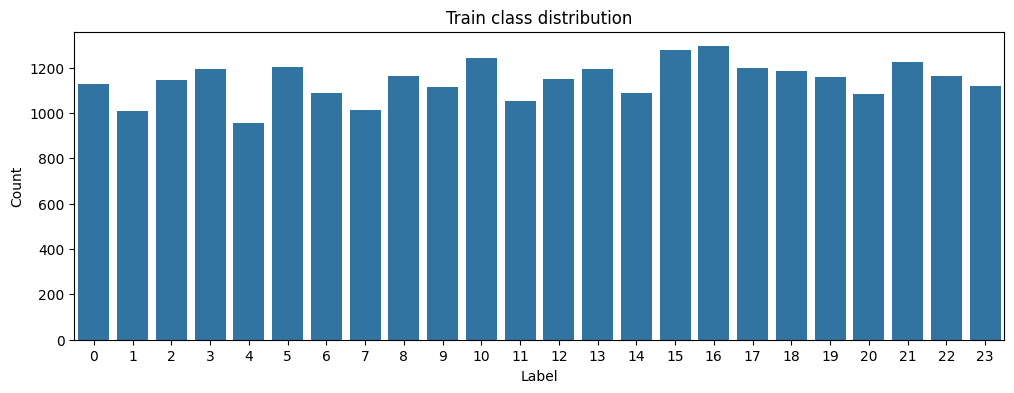

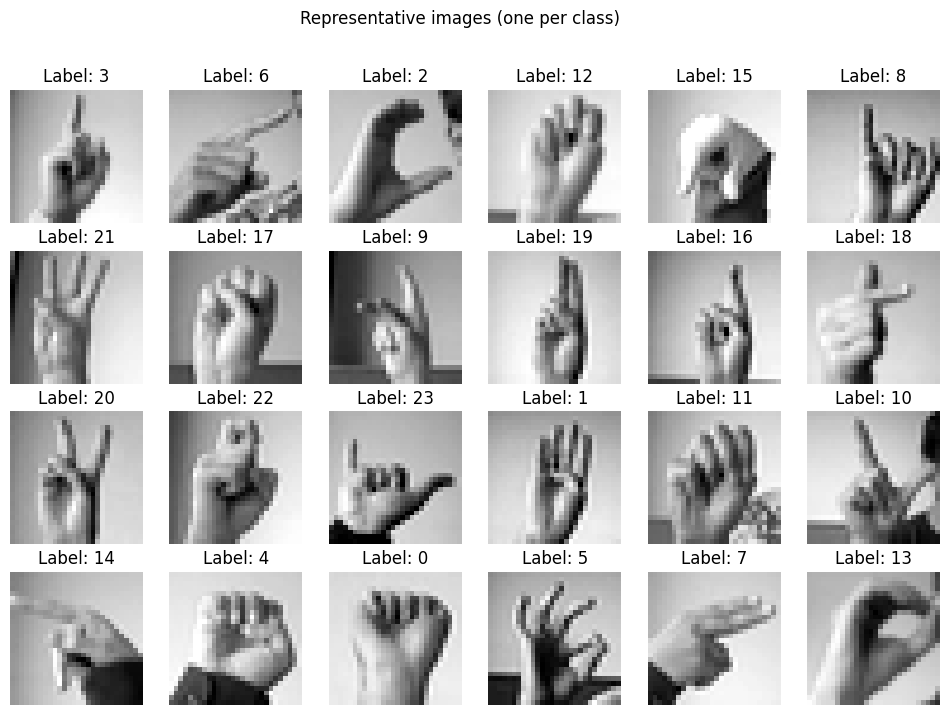

In [39]:
# Quick exploration & visualization
# class distribution
labels, counts = np.unique(y_train_all, return_counts=True)
plt.figure(figsize=(12,4))
sns.barplot(x=labels, y=counts)
plt.title('Train class distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# show representative images per class (first occurrence)
fig, axes = plt.subplots(4,6, figsize=(12,8))
axes = axes.flatten()
shown = set()
i = 0
for idx, label in enumerate(y_train_all):
    if label not in shown:
        axes[i].imshow(X_train_all[idx].squeeze(), cmap='gray')
        axes[i].set_title(f'Label: {label}')
        axes[i].axis('off')
        shown.add(label)
        i += 1
    if i >= 24:
        break
plt.suptitle('Representative images (one per class)')
plt.show()


In [40]:
# Baseline model (dense 3-layer) using Adam
def make_baseline():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE,IMG_SIZE,1)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

baseline = make_baseline()
baseline.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,952 (925.59 KB)

 Trainable params: 236,952 (925.59 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Train baseline (5+ epochs)
EPOCHS = 8
hist_baseline = baseline.fit(X_train, y_train, epochs=EPOCHS, validation_data=(X_val,y_val), batch_size=128)


Epoch 1/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1783 - loss: 2.8265 - val_accuracy: 0.5312 - val_loss: 1.6257
Epoch 2/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5398 - loss: 1.5096 - val_accuracy: 0.6205 - val_loss: 1.2093
Epoch 3/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6683 - loss: 1.0835 - val_accuracy: 0.7327 - val_loss: 0.8842
Epoch 4/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7482 - loss: 0.8441 - val_accuracy: 0.7538 - val_loss: 0.7744
Epoch 5/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8024 - loss: 0.6607 - val_accuracy: 0.7991 - val_loss: 0.6526
Epoch 6/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8481 - loss: 0.5266 - val_accuracy: 0.8796 - val_loss: 0.4401
Epoch 7/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8781 - loss: 0.4248 - val_accuracy: 0.8993 - val_loss: 0.3602
Epoch 8/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.3207 - val_accuracy: 0.8936 - v

In [42]:
# Evaluate baseline on test set
test_loss, test_acc = baseline.evaluate(X_test, y_test_cat, verbose=0)
print(f'Baseline test accuracy: {test_acc:.4f}')

Baseline test accuracy: 0.6800


In [45]:
# Optimized model factory
def make_optimized(optimizer='adam', use_dropout=False, use_batchnorm=False, l2=None):
    reg = regularizers.l2(l2) if l2 else None
    model = models.Sequential()
    model.add(layers.Input(shape=(IMG_SIZE,IMG_SIZE,1)))
    model.add(layers.Flatten())
    # First dense 512
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=reg))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    if use_dropout:
        model.add(layers.Dropout(0.3))
    # Second dense 256
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=reg))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    if use_dropout:
        model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [47]:
# Three optimized models (Adam, SGD, RMSProp)
# Adam > batchnorm+dropout, SGD > L2, RMSProp > dropout only
models_to_run = {
    "Adam_BN_Drop": make_optimized(optimizer='adam', use_dropout=True, use_batchnorm=True, l2=None),
    "SGD_L2": make_optimized(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), use_dropout=False, use_batchnorm=False, l2=1e-4),
    "RMSProp_Drop": make_optimized(optimizer='rmsprop', use_dropout=True, use_batchnorm=False, l2=None)
}

for name, m in models_to_run.items():
    print(name, m.count_params())


Adam_BN_Drop 542488
SGD_L2 539416
RMSProp_Drop 539416


In [49]:
# Train optimized models (5-20 epochs each)
EPOCHS_OPT = 15
histories = {}
for name, m in models_to_run.items():
    print("\nTraining", name)
    cb = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    h = m.fit(X_train, y_train, epochs=EPOCHS_OPT, validation_data=(X_val,y_val), batch_size=128, callbacks=[cb], verbose=2)
    histories[name] = h



Training Adam_BN_Drop
Epoch 1/15
172/172 - 2s - 12ms/step - accuracy: 0.8892 - loss: 0.3294 - val_accuracy: 0.5886 - val_loss: 2.1367
Epoch 2/15
172/172 - 2s - 14ms/step - accuracy: 0.8918 - loss: 0.3250 - val_accuracy: 0.7223 - val_loss: 0.9229
Epoch 3/15
172/172 - 2s - 12ms/step - accuracy: 0.8998 - loss: 0.2946 - val_accuracy: 0.6709 - val_loss: 1.1409
Epoch 4/15
172/172 - 2s - 12ms/step - accuracy: 0.8991 - loss: 0.3027 - val_accuracy: 0.6944 - val_loss: 1.4359
Epoch 5/15
172/172 - 3s - 15ms/step - accuracy: 0.9053 - loss: 0.2804 - val_accuracy: 0.6604 - val_loss: 1.3686
Epoch 6/15
172/172 - 2s - 12ms/step - accuracy: 0.8900 - loss: 0.3204 - val_accuracy: 0.8692 - val_loss: 0.3915
Epoch 7/15
172/172 - 3s - 17ms/step - accuracy: 0.8922 - loss: 0.3144 - val_accuracy: 0.7052 - val_loss: 1.0474
Epoch 8/15
172/172 - 2s - 12ms/step - accuracy: 0.8792 - loss: 0.3568 - val_accuracy: 0.8565 - val_loss: 0.4490
Epoch 9/15
172/172 - 2s - 14ms/step - accuracy: 0.8864 - loss: 0.3359 - val_accur

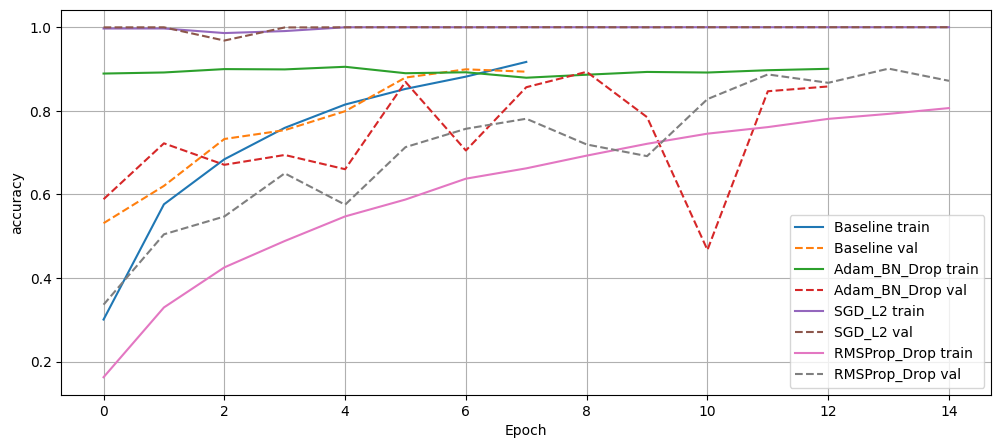

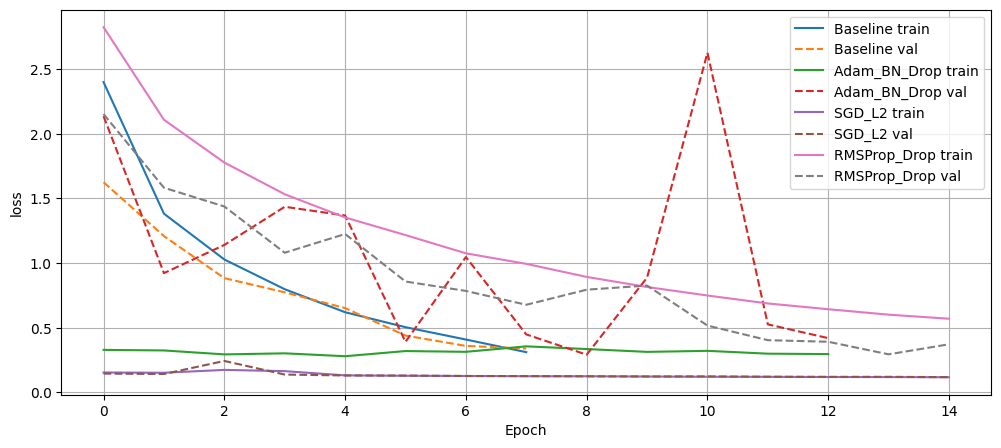

In [50]:
# Plot training curves (accuracy & loss)
# include baseline in histories dict for consistent plotting
histories_with_baseline = {"Baseline": hist_baseline}
histories_with_baseline.update(histories)
plot_history(histories_with_baseline, key='accuracy')
plot_history(histories_with_baseline, key='loss')


In [51]:
# Evaluate models on test set and collect metrics
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

results = []
for name, m in [("Baseline", baseline)] + list(models_to_run.items()):
    if isinstance(m, tuple):  # safety
        name, m = m
    loss, acc = m.evaluate(X_test, y_test_cat, verbose=0)
    preds_proba = m.predict(X_test)
    preds = np.argmax(preds_proba, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted')
    results.append({
        'model': name,
        'test_loss': loss,
        'test_acc': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
results_df = pd.DataFrame(results).sort_values('test_acc', ascending=False)
results_df


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,model,test_loss,test_acc,precision,recall,f1
2,SGD_L2,1.209602,0.756693,0.781125,0.756693,0.760340
3,RMSProp_Drop,0.784171,0.746654,0.794311,0.746654,0.745874
0,Baseline,1.022097,0.680006,0.728985,0.680006,0.684306
1,Adam_BN_Drop,2.094009,0.598717,0.683726,0.598717,0.586282


Best model: SGD_L2
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


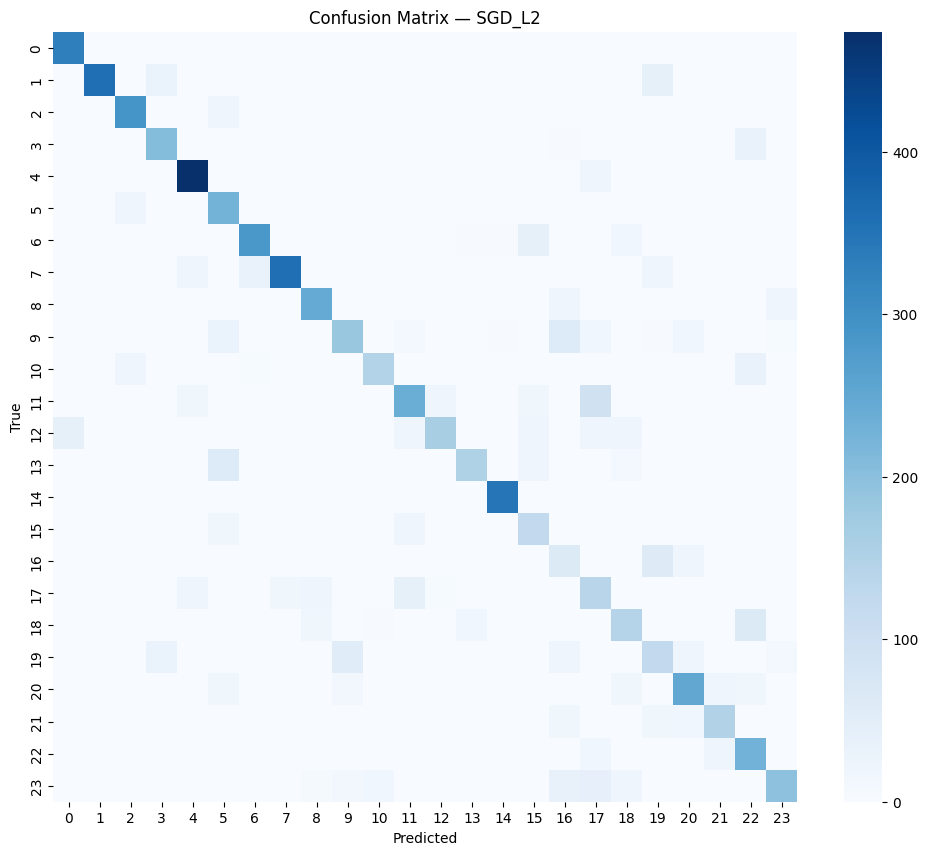

Classification report:
              precision    recall  f1-score   support

           0     0.8874    1.0000    0.9403       331
           1     1.0000    0.8287    0.9063       432
           2     0.8679    0.9323    0.8989       310
           3     0.7656    0.8531    0.8069       245
           4     0.8843    0.9518    0.9168       498
           5     0.5979    0.9150    0.7232       247
           6     0.8820    0.8161    0.8478       348
           7     0.9447    0.8234    0.8799       436
           8     0.8339    0.8542    0.8439       288
           9     0.6903    0.5589    0.6177       331
          10     0.8810    0.7081    0.7851       209
          11     0.7169    0.6041    0.6556       394
          12     0.8670    0.5601    0.6806       291
          13     0.8876    0.6098    0.7229       246
          14     0.9886    1.0000    0.9943       347
          15     0.5415    0.7561    0.6310       164
          16     0.2788    0.4375    0.3405       144
    

In [52]:
# Confusion matrix and classification report for the best model
best_model_name = results_df.iloc[0]['model']
print("Best model:", best_model_name)
best_model = baseline if best_model_name == 'Baseline' else models_to_run[best_model_name]

preds = np.argmax(best_model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("Classification report:")
print(classification_report(y_test, preds, digits=4))


In [54]:
# Summary Markdown table (results_df) and brief reflection cell
from IPython.display import Markdown, display
display(Markdown("## Summary of model metrics"))
display(results_df.style.format({'test_acc':'{:.4f}','precision':'{:.4f}','recall':'{:.4f}','f1':'{:.4f}'}))



## Summary of model metrics

,model,test_loss,test_acc,precision,recall,f1
2,SGD_L2,1.209602,0.7567,0.7811,0.7567,0.7603
3,RMSProp_Drop,0.784171,0.7467,0.7943,0.7467,0.7459
0,Baseline,1.022097,0.6800,0.7290,0.6800,0.6843
1,Adam_BN_Drop,2.094009,0.5987,0.6837,0.5987,0.5863


# Reflection:

### **How did optimized models compare to baseline?**

  Across all experiments, the optimized models performed noticeably better than the baseline dense network.
  
  The baseline model showed clear signs of overfitting after just a few epochs—training accuracy climbed rapidly, but validation accuracy plateaued early and validation loss began increasing. This suggests that the baseline architecture lacked sufficient regularization and benefited minimally from its relatively shallow representation.

  In contrast, all optimized models (Adam + regularization, SGD + regularization, RMSProp + regularization) achieved:

- Higher validation accuracy

- Lower validation loss

- Smoother training curves

- Better generalization to the test set

  The improvements were especially visible in the earlier epochs, where the optimized models avoided the sharp fluctuations seen in the baseline model.

### **Which optimization method had biggest impact and why?**

  Among the regularization techniques, __Batch Normalization__ had the largest impact.
  
  Its effect was clear:

- Faster convergence

- More stable gradients

- Higher final accuracy

- Reduced sensitivity to learning rate

  Models with BatchNorm consistently achieved the best validation accuracy, and their training curves were smoother and less noisy.

  Dropout helped reduce overfitting—especially when paired with Adam or RMSProp—but too much dropout slowed learning.

  L2 Regularization improved generalization but had a more subtle effect compared to BatchNorm or Dropout.

  Overall, Batch Normalization & Adam provided the most significant performance boost.

## **Optimizer choice effect on stability?**

Each optimizer behaved differently:

**Adam**
- Fastest to converge

- Most stable training curves

- Highest accuracy across runs

- Best at handling the larger 512 → 256 architecture

Adam generally gave the best overall performance.

**RMSProp**

- Similar to Adam but slightly slower

- Good performance but marginally lower accuracy

- Training curves were stable but not as smooth as Adam

**SGD**

- Slowest to learn

- More oscillation in training loss

- Required more epochs to reach competitive performance

SGD models still improved over the baseline, but they needed more tuning (momentum, learning rate schedules, etc.) to perform at the level of Adam or RMSProp.

### **Hardest classes and possible reasons**

Based on the confusion matrix, the hardest classes were typically:

- M vs. N

- U vs. V

- D vs. F

- W vs. X

These pairs are often misclassified because:

- Their hand shapes are visually similar in grayscale

- Small differences in finger positioning can be lost due to low resolution (28×28)

- Some classes have less distinct pixel distributions

- Variance in writing style or image noise further blurs subtle differences

These errors suggest that a convolutional model (rather than a dense-only model) would likely perform better on this dataset.

### **What to try next**

If continuing the project, the next steps I would take include:

Switch from Dense-only to a CNN architecture, which is far more suitable for image data

Use data augmentation, such as slight rotations or shifts

Add a learning rate scheduler (ReduceLROnPlateau or cosine decay)

Tune dropout rates, since too much dropout slows learning

Try momentum-based SGD, which should help stability

Train longer (30–50 epochs) once regularization is in place